# 02 — Operating Result Timeline Report

**Propósito.** Construir una lectura temporal de la operación patrimonial: cuatro años de historia, cambios de régimen, y cierre semestral 2026-H1.

**Pregunta humana.**  
¿Cómo cambió la operación patrimonial a través del tiempo, bajo distintos regímenes de administración, y qué muestra el cierre semestral 2026?

**Idea rectora.**  
Este notebook no busca producir una foto aislada ni un total agregado que mezcle etapas. La unidad base es mensual; después se agrupa por año, semestre, trimestre y régimen.

**Regla contable central.**

```text
Resultado operativo limpio = ingresos operativos - costos operativos
```

Los aportes familiares, funding y retiros/distribuciones se muestran al lado, pero no se tratan como ingresos operativos.

## 0. Notebook contract

Este notebook:

- analiza la evolución temporal de la operación;
- usa como base los artifacts generados por el backend contable;
- construye una tabla mensual canónica;
- segmenta por regímenes de administración/trazabilidad;
- produce un cierre específico de 2026-H1;
- exporta tablas, figuras, caveats, QA y un reporte markdown/html.

Este notebook **no**:

- redefine la contabilidad base;
- reemplaza el ledger canónico;
- calcula saldo jurídico final por actor;
- trata aportes familiares como ingresos operativos;
- reemplaza auditoría externa o asesoramiento legal.

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import re
import html
from datetime import datetime
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

## 1. Load latest run context

La notebook puede correr desde la raíz del repo o desde `notebooks/accounting/`. Intenta resolver `out/metrics/latest`, `out/run/accounting/latest`, `out/debt_resolution/latest` y `out/human_reports/latest`.

Si algún artifact no existe, no falla inmediatamente: registra caveats y permite generar una salida parcial.

In [6]:
# -----------------------------
# User-facing parameters
# -----------------------------

HISTORY_START = "2022-01-01"
HISTORY_END = "2026-06-30"

CLOSE_YEAR = 2026
CLOSE_SEMESTER = 1  # 1 = Jan-Jun, 2 = Jul-Dec

# If "latest", output path is out/professional_pack/latest/operating_result/
REPORT_PERIOD = "latest"

# -----------------------------
# Path resolution
# -----------------------------

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "accounting").exists() and (candidate / "out").exists():
            return candidate
    # fallback: if running in a fresh location, use current working dir
    return cwd

REPO = resolve_repo_root()
OUT = REPO / "out"

METRICS = OUT / "metrics" / "latest"
DEBT = OUT / "debt_resolution" / "latest"
RUN = OUT / "run" / "accounting" / "latest"
HUMAN = OUT / "human_reports" / "latest"

PACK = OUT / "professional_pack" / REPORT_PERIOD / "operating_result"
FIGURES = PACK / "figures"
TABLES = PACK / "tables"

for p in [PACK, FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("REPO:", REPO)
print("METRICS:", METRICS, "exists=", METRICS.exists())
print("RUN:", RUN, "exists=", RUN.exists())
print("DEBT:", DEBT, "exists=", DEBT.exists())
print("PACK:", PACK)

REPO: /home/matias/repos/accounting-backend
METRICS: /home/matias/repos/accounting-backend/out/metrics/latest exists= True
RUN: /home/matias/repos/accounting-backend/out/run/accounting/latest exists= True
DEBT: /home/matias/repos/accounting-backend/out/debt_resolution/latest exists= True
PACK: /home/matias/repos/accounting-backend/out/professional_pack/latest/operating_result


In [7]:
# -----------------------------
# Generic IO helpers
# -----------------------------

caveats = []
qa_rows = []

def add_caveat(scope, message, severity="warning"):
    caveats.append({"scope": scope, "severity": severity, "message": message})

def add_qa(check, status, details=""):
    qa_rows.append({"check": check, "status": status, "details": details})

def read_csv_safe(path, **kwargs):
    path = Path(path)
    if not path.exists():
        add_caveat("missing_file", f"Missing file: {path}", "warning")
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        add_caveat("read_error", f"Could not read {path}: {e}", "error")
        return pd.DataFrame()

def list_csvs(*dirs):
    files = []
    for d in dirs:
        d = Path(d)
        if d.exists():
            files.extend(sorted(d.rglob("*.csv")))
    return files

def normalize_columns(df):
    if df.empty:
        return df
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def find_col(df, candidates=None, contains=None):
    if df.empty:
        return None
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}
    if candidates:
        for cand in candidates:
            if cand.lower() in lower:
                return lower[cand.lower()]
    if contains:
        for pattern in contains:
            for c in cols:
                if pattern.lower() in c.lower():
                    return c
    return None

def coerce_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def fmt_money(x):
    if pd.isna(x):
        return "s/d"
    try:
        x = float(x)
    except Exception:
        return "s/d"
    sign = "-" if x < 0 else ""
    return f"{sign}$ {abs(x):,.0f}".replace(",", ".")

def fmt_num(x):
    if pd.isna(x):
        return "s/d"
    try:
        return f"{float(x):,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    except Exception:
        return str(x)

def parse_period_to_month(value):
    # "\"\"Return pandas Period[M] from common period labels: YYYY-MM, YYYYQ1, 2026, dates.\"\"\"
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    if not s:
        return pd.NaT

    # YYYY-MM or YYYY/MM
    m = re.match(r"^(\\d{4})[-/](\\d{1,2})$", s)
    if m:
        y, mo = int(m.group(1)), int(m.group(2))
        if 1 <= mo <= 12:
            return pd.Period(f"{y}-{mo:02d}", freq="M")

    # Full date
    try:
        dt = pd.to_datetime(s, errors="raise")
        return pd.Period(dt, freq="M")
    except Exception:
        pass

    # Quarter: 2026Q2 or 2026-Q2
    m = re.match(r"^(\\d{4})[- ]?Q([1-4])$", s, flags=re.IGNORECASE)
    if m:
        y, q = int(m.group(1)), int(m.group(2))
        # represent quarterly value at quarter end month; do not expand yet
        mo = q * 3
        return pd.Period(f"{y}-{mo:02d}", freq="M")

    # Year only
    m = re.match(r"^(\\d{4})$", s)
    if m:
        y = int(m.group(1))
        return pd.Period(f"{y}-12", freq="M")

    return pd.NaT

def infer_period_col(df):
    return find_col(
        df,
        candidates=["period_month", "month", "period", "period_key", "period_label", "date", "fecha", "year_month"],
        contains=["month", "period", "fecha", "date"]
    )

def infer_value_col(df, preferred_contains=None):
    if df.empty:
        return None
    if preferred_contains is None:
        preferred_contains = []
    candidates = ["value", "amount", "amount_ars", "metric_value", "total", "saldo", "balance", "monto"]
    for c in candidates:
        col = find_col(df, candidates=[c])
        if col is not None:
            return col
    for pat in preferred_contains:
        col = find_col(df, contains=[pat])
        if col is not None:
            return col
    # last numeric-looking column
    numeric_cols = []
    for c in df.columns:
        vals = pd.to_numeric(df[c], errors="coerce")
        if vals.notna().sum() > 0:
            numeric_cols.append(c)
    return numeric_cols[-1] if numeric_cols else None

def detect_frequency_from_period_label(s):
    if pd.isna(s):
        return "unknown"
    s = str(s)
    if re.match(r"^\\d{4}-\\d{1,2}$", s):
        return "M"
    if re.match(r"^\\d{4}[- ]?Q[1-4]$", s, flags=re.IGNORECASE):
        return "Q"
    if re.match(r"^\\d{4}$", s):
        return "Y"
    try:
        dt = pd.to_datetime(s, errors="raise")
        # A date can still represent monthly data; assume M for notebook reporting.
        return "M"
    except Exception:
        return "unknown"

In [8]:
# -----------------------------
# Load canonical artifacts
# -----------------------------

metric_registry = normalize_columns(read_csv_safe(METRICS / "metric_registry.csv"))
metric_values = normalize_columns(read_csv_safe(METRICS / "metric_values.csv"))
validation_report = normalize_columns(read_csv_safe(METRICS / "validation_report.csv"))

ledger = normalize_columns(read_csv_safe(RUN / "ledger_canonical.csv"))

metric_view_files = list_csvs(METRICS / "metric_views")
run_view_files = list_csvs(RUN / "views")
debt_files = list_csvs(DEBT)

print("metric_registry:", metric_registry.shape)
print("metric_values:", metric_values.shape)
print("validation_report:", validation_report.shape)
print("ledger:", ledger.shape)
print("metric_view_files:", len(metric_view_files))
print("run_view_files:", len(run_view_files))
print("debt_files:", len(debt_files))

add_qa("metric_registry_loaded", "ok" if not metric_registry.empty else "missing", str(metric_registry.shape))
add_qa("metric_values_loaded", "ok" if not metric_values.empty else "missing", str(metric_values.shape))
add_qa("ledger_loaded", "ok" if not ledger.empty else "missing", str(ledger.shape))

metric_registry: (17, 14)
metric_values: (287, 10)
validation_report: (1, 4)
ledger: (1192, 26)
metric_view_files: 14
run_view_files: 11
debt_files: 9


## 2. Build monthly spine

La columna vertebral del reporte es una serie mensual continua. Aunque falten datos, el mes queda visible y marcado. Esto evita que la historia se convierta en una selección oportunista de períodos.

In [9]:
# -----------------------------
# Monthly spine
# -----------------------------

start_month = pd.Period(pd.to_datetime(HISTORY_START), freq="M")
end_month = pd.Period(pd.to_datetime(HISTORY_END), freq="M")

months = pd.period_range(start_month, end_month, freq="M")
monthly = pd.DataFrame({"period_month": months.astype(str)})
monthly["date"] = monthly["period_month"].apply(lambda x: pd.Period(x, freq="M").to_timestamp())
monthly["year"] = monthly["date"].dt.year
monthly["month"] = monthly["date"].dt.month
monthly["quarter"] = monthly["date"].dt.to_period("Q").astype(str)
monthly["semester"] = monthly["year"].astype(str) + "H" + np.where(monthly["month"] <= 6, "1", "2")
monthly.head(), monthly.tail()

(  period_month       date  year  month quarter semester
 0      2022-01 2022-01-01  2022      1  2022Q1   2022H1
 1      2022-02 2022-02-01  2022      2  2022Q1   2022H1
 2      2022-03 2022-03-01  2022      3  2022Q1   2022H1
 3      2022-04 2022-04-01  2022      4  2022Q2   2022H1
 4      2022-05 2022-05-01  2022      5  2022Q2   2022H1,
    period_month       date  year  month quarter semester
 49      2026-02 2026-02-01  2026      2  2026Q1   2026H1
 50      2026-03 2026-03-01  2026      3  2026Q1   2026H1
 51      2026-04 2026-04-01  2026      4  2026Q2   2026H1
 52      2026-05 2026-05-01  2026      5  2026Q2   2026H1
 53      2026-06 2026-06-01  2026      6  2026Q2   2026H1)

## 3. Regime map

El análisis por régimen es manual o semimanual por diseño: no todo cambio de administración se deduce de la contabilidad.

La notebook busca un archivo de regímenes en:

- `notebooks/accounting/regime_periods.csv`
- `config/regime_periods.csv`
- `notes/regime_periods.csv`

Si no existe, usa un mapa default editable y lo exporta como `regime_periods_used.csv`.

In [10]:
# -----------------------------
# Regime map
# -----------------------------

def load_regime_periods():
    candidates = [
        REPO / "notebooks" / "accounting" / "regime_periods.csv",
        REPO / "config" / "regime_periods.csv",
        REPO / "notes" / "regime_periods.csv",
    ]
    for path in candidates:
        if path.exists():
            df = read_csv_safe(path)
            if not df.empty:
                add_qa("regime_map_loaded", "ok", str(path))
                return df, str(path)

    default = pd.DataFrame([
        {
            "regime_id": "R1",
            "regime_label": "Base heredada / informal",
            "start_date": "2022-01-01",
            "end_date": "2022-12-31",
            "description": "Primer tramo reconstruido; completar descripción.",
            "admin_mode": "informal",
            "traceability_level": "baja",
            "notes": "Default editable.",
        },
        {
            "regime_id": "R2",
            "regime_label": "Transición / conflicto",
            "start_date": "2023-01-01",
            "end_date": "2023-12-31",
            "description": "Tramo de transición o mayor tensión; completar.",
            "admin_mode": "mixto",
            "traceability_level": "media",
            "notes": "Default editable.",
        },
        {
            "regime_id": "R3",
            "regime_label": "Reconstrucción contable",
            "start_date": "2024-01-01",
            "end_date": "2025-12-31",
            "description": "Mayor capacidad de ledger, métricas y reportes; completar.",
            "admin_mode": "mixto",
            "traceability_level": "media-alta",
            "notes": "Default editable.",
        },
        {
            "regime_id": "R4",
            "regime_label": "Cierre semestral 2026",
            "start_date": "2026-01-01",
            "end_date": "2026-06-30",
            "description": "Semestre actual de cierre y decisión.",
            "admin_mode": "revisión",
            "traceability_level": "alta",
            "notes": "Default editable.",
        },
    ])
    add_caveat("regime_map", "No custom regime_periods.csv found. Using editable default regime map.", "warning")
    add_qa("regime_map_loaded", "default", "No regime_periods.csv found")
    return default, "default"

regimes, regime_source = load_regime_periods()
regimes = normalize_columns(regimes)

# Parse and apply regimes
regimes["start_period"] = regimes["start_date"].apply(parse_period_to_month)
regimes["end_period"] = regimes["end_date"].apply(parse_period_to_month)

def assign_regime(period_month):
    p = pd.Period(period_month, freq="M")
    for _, r in regimes.iterrows():
        if pd.notna(r["start_period"]) and pd.notna(r["end_period"]) and r["start_period"] <= p <= r["end_period"]:
            return pd.Series({
                "regime_id": r.get("regime_id", "UNKNOWN"),
                "regime_label": r.get("regime_label", "Sin régimen"),
                "admin_mode": r.get("admin_mode", ""),
                "traceability_level": r.get("traceability_level", ""),
            })
    return pd.Series({"regime_id": "UNMAPPED", "regime_label": "Sin mapear", "admin_mode": "", "traceability_level": ""})

monthly = pd.concat([monthly, monthly["period_month"].apply(assign_regime)], axis=1)
regimes.drop(columns=["start_period", "end_period"], errors="ignore").to_csv(PACK / "regime_periods_used.csv", index=False)

display(regimes.drop(columns=["start_period", "end_period"], errors="ignore"))
monthly.head()

,regime_id,regime_label,start_date,end_date,description,admin_mode,traceability_level,notes
0,R1,Base heredada / informal,2022-01-01,2022-12-31,Primer tramo reconstruido; completar descripción.,informal,baja,Default editable.
1,R2,Transición / conflicto,2023-01-01,2023-12-31,Tramo de transición o mayor tensión; completar.,mixto,media,Default editable.
2,R3,Reconstrucción contable,2024-01-01,2025-12-31,"Mayor capacidad de ledger, métricas y reportes...",mixto,media-alta,Default editable.
3,R4,Cierre semestral 2026,2026-01-01,2026-06-30,Semestre actual de cierre y decisión.,revisión,alta,Default editable.


,period_month,date,year,month,quarter,semester,regime_id,regime_label,admin_mode,traceability_level
0,2022-01,2022-01-01,2022,1,2022Q1,2022H1,R1,Base heredada / informal,informal,baja
1,2022-02,2022-02-01,2022,2,2022Q1,2022H1,R1,Base heredada / informal,informal,baja
2,2022-03,2022-03-01,2022,3,2022Q1,2022H1,R1,Base heredada / informal,informal,baja
3,2022-04,2022-04-01,2022,4,2022Q2,2022H1,R1,Base heredada / informal,informal,baja
4,2022-05,2022-05-01,2022,5,2022Q2,2022H1,R1,Base heredada / informal,informal,baja


## 4. Resolve operating metrics and fallback sources

Este segmento construye series mensuales con jerarquía explícita:

1. Métricas limpias (`IS.REVENUE.TOTAL`, `IS.NET.OPERATING`) si existen.
2. Métricas legacy solo cuando sean necesarias y con caveat.
3. Fallbacks desde `metric_views/`, `views/` y deuda.
4. Si no hay fuente, el KPI queda faltante y la narrativa se degrada.

In [13]:
# -----------------------------
# Metric extraction helpers
# -----------------------------

def metric_id_col(df):
    return find_col(df, candidates=["metric_id", "id"])

def metric_period_col(df):
    return find_col(df, candidates=["period", "period_key", "period_label", "period_month", "date", "year", "quarter"])

def metric_value_col(df):
    return find_col(df, candidates=["value", "metric_value", "amount", "amount_ars", "total"])

def metric_frequency_col(df):
    return find_col(df, candidates=["frequency", "freq", "period_type", "grain", "period_kind"])

def extract_metric_series(metric_id, preferred_freq="M"):
    # \"\"\"Extract a metric_id as a monthly-like series where possible.\"\"\"
    if metric_values.empty:
        return pd.DataFrame(columns=["period_month", metric_id, "source_metric", "source_file", "source_frequency"])

    mid_col = metric_id_col(metric_values)
    per_col = metric_period_col(metric_values)
    val_col = metric_value_col(metric_values)
    freq_col = metric_frequency_col(metric_values)

    if not all([mid_col, per_col, val_col]):
        add_caveat("metric_values_schema", f"Could not infer metric_values columns for {metric_id}.", "warning")
        return pd.DataFrame(columns=["period_month", metric_id, "source_metric", "source_file", "source_frequency"])

    sub = metric_values[metric_values[mid_col].astype(str) == metric_id].copy()
    if sub.empty:
        return pd.DataFrame(columns=["period_month", metric_id, "source_metric", "source_file", "source_frequency"])

    if freq_col is not None and preferred_freq is not None:
        # Prefer monthly if available. If not, keep all and caveat.
        monthly_sub = sub[sub[freq_col].astype(str).str.upper().isin([preferred_freq.upper(), "MONTH", "MONTHLY", "M"])]
        if not monthly_sub.empty:
            sub = monthly_sub

    sub["period_month"] = sub[per_col].apply(parse_period_to_month).astype("period[M]").astype(str)
    sub[metric_id] = coerce_numeric(sub[val_col])
    sub["source_metric"] = metric_id
    sub["source_file"] = str(METRICS / "metric_values.csv")
    if freq_col is not None:
        sub["source_frequency"] = sub[freq_col].astype(str)
    else:
        sub["source_frequency"] = sub[per_col].apply(detect_frequency_from_period_label)

    # If metric_values has multiple rows per period/frequency, sum for flows and last for stocks are not known here.
    # For this report we aggregate by period with sum for flow-like metrics and last for closing-like metrics later.
    out = sub[["period_month", metric_id, "source_metric", "source_file", "source_frequency"]].copy()
    return out

def aggregate_series(df, value_col, agg="sum"):
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=["period_month", value_col])
    tmp = df.copy()
    tmp[value_col] = coerce_numeric(tmp[value_col])
    if agg == "last":
        return tmp.sort_values("period_month").groupby("period_month", as_index=False)[value_col].last()
    return tmp.groupby("period_month", as_index=False)[value_col].sum(min_count=1)

def search_file_candidates(files, include_patterns, exclude_patterns=None):
    if exclude_patterns is None:
        exclude_patterns = []
    out = []
    for f in files:
        s = str(f).lower()
        if any(p.lower() in s for p in include_patterns) and not any(p.lower() in s for p in exclude_patterns):
            out.append(f)
    return sorted(out)

def extract_generic_monthly_from_file(path, out_col, value_patterns=None, filters=None, agg="sum"):
    df = normalize_columns(read_csv_safe(path))
    if df.empty:
        return pd.DataFrame(columns=["period_month", out_col])
    if filters:
        for col_pat, val_pat in filters:
            col = find_col(df, contains=[col_pat])
            if col is not None:
                df = df[df[col].astype(str).str.contains(val_pat, case=False, na=False)]
    per_col = infer_period_col(df)
    val_col = infer_value_col(df, preferred_contains=value_patterns or [])
    if per_col is None or val_col is None:
        return pd.DataFrame(columns=["period_month", out_col])
    tmp = df.copy()
    tmp["period_month"] = tmp[per_col].apply(parse_period_to_month).astype("period[M]").astype(str)
    tmp[out_col] = coerce_numeric(tmp[val_col])
    tmp["source_file"] = str(path)
    return aggregate_series(tmp[["period_month", out_col, "source_file"]], out_col, agg=agg)

def first_nonempty_series(candidates):
    for label, df, caveat in candidates:
        if not df.empty and df.shape[0] > 0 and df.iloc[:, 1].notna().sum() > 0:
            return label, df, caveat
    return None, pd.DataFrame(), None

def resolve_series(name, preferred_metrics, fallback_files, value_patterns=None, agg="sum", legacy_metrics=None):
    # \"\"\"Resolve a canonical series from metrics first, then files.\"\"\"
    legacy_metrics = legacy_metrics or []
    attempts = []

    for mid in preferred_metrics:
        raw = extract_metric_series(mid)
        if not raw.empty:
            value = aggregate_series(raw.rename(columns={mid: name}), name, agg=agg)
            attempts.append((f"metric:{mid}", value, None))
    for mid in legacy_metrics:
        raw = extract_metric_series(mid)
        if not raw.empty:
            value = aggregate_series(raw.rename(columns={mid: name}), name, agg=agg)
            attempts.append((f"legacy_metric:{mid}", value, f"Used legacy metric {mid} for {name}."))

    for path in fallback_files:
        value = extract_generic_monthly_from_file(path, name, value_patterns=value_patterns, agg=agg)
        if not value.empty:
            attempts.append((f"file:{path.name}", value, f"Used fallback file {path} for {name}."))

    label, df, cav = first_nonempty_series(attempts)
    if label is None:
        add_caveat(name, f"No usable source found for {name}.", "warning")
        return pd.DataFrame(columns=["period_month", name]), "missing"
    if cav:
        add_caveat(name, cav, "warning")
    return df, label

In [14]:
# -----------------------------
# Candidate fallback files
# -----------------------------

all_view_files = metric_view_files + run_view_files

rent_files = search_file_candidates(all_view_files, ["rent", "renta", "income_statement"], exclude_patterns=["draw"])
opex_files = search_file_candidates(all_view_files, ["opex", "cost", "gasto", "expense", "flow_type", "income_statement"])
funding_files = search_file_candidates(all_view_files, ["contrib", "fund", "aporte"])
draws_files = search_file_candidates(all_view_files, ["draw", "retiro", "personal"])
cash_files = search_file_candidates(all_view_files, ["cash", "caja", "balance_cash", "fondos"])
debt_balance_files = search_file_candidates(debt_files + all_view_files, ["debt_balance", "balance_debt", "debt"])

print("rent_files:", [f.name for f in rent_files[:10]])
print("opex_files:", [f.name for f in opex_files[:10]])
print("funding_files:", [f.name for f in funding_files[:10]])
print("draws_files:", [f.name for f in draws_files[:10]])
print("cash_files:", [f.name for f in cash_files[:10]])
print("debt_balance_files:", [f.name for f in debt_balance_files[:10]])

rent_files: ['income_statement_monthly_last6.csv', 'rent_rollup_by_detail_m_last6.csv', 'rent_rollup_by_place_m_last6.csv', 'renta_pivot.party_currency.csv']
opex_files: ['flow_type_rollup_m_last6.csv', 'income_statement_monthly_last6.csv', 'opex_by_category_m_last12.csv', 'opex_by_category_y.csv', 'v_opex_category_monthly.csv']
funding_files: ['contrib_rollup_by_party_m_last12.csv', 'contrib_rollup_by_party_y.csv', 'v_contributions_monthly.csv']
draws_files: ['draws_discipline_monthly_last6.csv']
cash_files: ['cash_position_monthly_last12.csv', 'fondos_wide.csv', 'v_cashflow_monthly.csv']
debt_balance_files: ['debt_allocations.csv', 'debt_balance_daily.csv', 'debt_balance_monthly.csv', 'debt_balance_quarterly.csv', 'debt_balance_yearly.csv', 'debt_open_items.csv', 'debt_repayment_events.csv', 'debt_resolution_timeline.csv', 'debt_status_reconciliation.csv', 'debt_balance_monthly_last12.csv']


In [15]:
# -----------------------------
# Resolve monthly series
# -----------------------------

rent_total, rent_source = resolve_series(
    "rent_total",
    preferred_metrics=["IS.RENT.TOTAL", "IS.REVENUE.TOTAL"],
    legacy_metrics=[],
    fallback_files=rent_files,
    value_patterns=["rent", "renta", "total", "amount", "value"],
    agg="sum",
)

opex_total, opex_source = resolve_series(
    "opex_total",
    preferred_metrics=["IS.OPEX.TOTAL"],
    legacy_metrics=[],
    fallback_files=opex_files,
    value_patterns=["opex", "cost", "gasto", "expense", "total", "amount", "value"],
    agg="sum",
)

funding_total, funding_source = resolve_series(
    "funding_total",
    preferred_metrics=["FUND.CONTRIB.TOTAL"],
    legacy_metrics=["IS.CONTRIB.TOTAL"],
    fallback_files=funding_files,
    value_patterns=["contrib", "aporte", "fund", "total", "amount", "value"],
    agg="sum",
)

draws_total, draws_source = resolve_series(
    "draws_total",
    preferred_metrics=["DIST.DRAWS.PERSONAL"],
    legacy_metrics=["IS.DRAWS.PERSONAL"],
    fallback_files=draws_files,
    value_patterns=["draw", "retiro", "personal", "total", "amount", "value"],
    agg="sum",
)

cash_closing, cash_source = resolve_series(
    "cash_closing",
    preferred_metrics=["BS.CASH.TOTAL"],
    legacy_metrics=[],
    fallback_files=cash_files,
    value_patterns=["cash", "caja", "saldo", "balance", "total", "amount", "value"],
    agg="last",
)

debt_closing, debt_source = resolve_series(
    "debt_closing",
    preferred_metrics=["ID.TOTAL.CLOSING_BALANCE", "BS.DEBT.TOTAL.OPEN"],
    legacy_metrics=[],
    fallback_files=debt_balance_files,
    value_patterns=["debt", "deuda", "open", "balance", "saldo", "total", "amount", "value"],
    agg="last",
)

sources = pd.DataFrame([
    {"series": "rent_total", "source": rent_source},
    {"series": "opex_total", "source": opex_source},
    {"series": "funding_total", "source": funding_source},
    {"series": "draws_total", "source": draws_source},
    {"series": "cash_closing", "source": cash_source},
    {"series": "debt_closing", "source": debt_source},
])
display(sources)
sources.to_csv(PACK / "operating_result_sources.csv", index=False)

,series,source
0,rent_total,file:renta_pivot.party_currency.csv
1,opex_total,metric:IS.OPEX.TOTAL
2,funding_total,legacy_metric:IS.CONTRIB.TOTAL
3,draws_total,legacy_metric:IS.DRAWS.PERSONAL
4,cash_closing,metric:BS.CASH.TOTAL
5,debt_closing,file:debt_resolution_timeline.csv


## 5. Build the canonical monthly operating table

Esta tabla es el corazón del reporte. Todas las secciones posteriores se apoyan en ella.

La regla central es:

```text
net_operating = rent_total - opex_total
```

Funding, draws, cash y debt se incorporan para contexto temporal, no para redefinir el resultado operativo.

In [16]:
# -----------------------------
# Build operating_result_monthly
# -----------------------------

operating_monthly = monthly.copy()

for df in [rent_total, opex_total, funding_total, draws_total, cash_closing, debt_closing]:
    if not df.empty:
        operating_monthly = operating_monthly.merge(df, on="period_month", how="left")

for col in ["rent_total", "opex_total", "funding_total", "draws_total", "cash_closing", "debt_closing"]:
    if col not in operating_monthly.columns:
        operating_monthly[col] = np.nan

# Clean operating result: do NOT use funding.
operating_monthly["net_operating"] = operating_monthly["rent_total"] - operating_monthly["opex_total"]

# Coverage-like context metrics
operating_monthly["coverage_after_funding"] = operating_monthly["net_operating"] + operating_monthly["funding_total"].fillna(0)
operating_monthly["coverage_after_funding_and_draws"] = operating_monthly["coverage_after_funding"] - operating_monthly["draws_total"].fillna(0)

# Data quality status by row
def data_quality_status(row):
    missing = []
    for c in ["rent_total", "opex_total"]:
        if pd.isna(row[c]):
            missing.append(c)
    if len(missing) == 0:
        return "ok"
    if len(missing) == 1:
        return "partial_missing_" + missing[0]
    return "missing_core_operating_data"

operating_monthly["data_quality_flag"] = operating_monthly.apply(data_quality_status, axis=1)

# Restrict to history window explicitly
operating_monthly = operating_monthly[(operating_monthly["date"] >= pd.to_datetime(HISTORY_START)) & (operating_monthly["date"] <= pd.to_datetime(HISTORY_END))].copy()

operating_monthly.to_csv(PACK / "operating_result_monthly.csv", index=False)
operating_monthly.to_csv(TABLES / "operating_result_monthly.csv", index=False)

display(operating_monthly.tail(12))

,period_month,date,year,month,quarter,semester,regime_id,regime_label,admin_mode,traceability_level,rent_total,opex_total,funding_total,draws_total,cash_closing,debt_closing,net_operating,coverage_after_funding,coverage_after_funding_and_draws,data_quality_flag
42,2025-07,2025-07-01,2025,7,2025Q3,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,11391545.63,1226762.0,9465314.0,100.0,NaN,-11391165.63,-10164403.63,-19629717.63,ok
43,2025-08,2025-08-01,2025,8,2025Q3,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,partial_missing_opex_total
44,2025-09,2025-09-01,2025,9,2025Q3,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,partial_missing_opex_total
45,2025-10,2025-10-01,2025,10,2025Q4,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,15288117.38,1783339.0,11953086.0,100.0,380.0,-15287737.38,-13504398.38,-25457484.38,ok
46,2025-11,2025-11-01,2025,11,2025Q4,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,NaN,NaN,NaN,NaN,380.0,NaN,NaN,NaN,partial_missing_opex_total
47,2025-12,2025-12-01,2025,12,2025Q4,2025H2,R3,Reconstrucción contable,mixto,media-alta,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,partial_missing_opex_total
48,2026-01,2026-01-01,2026,1,2026Q1,2026H1,R4,Cierre semestral 2026,revisión,alta,380.0,47340336.90,2010000.0,35958512.0,0.0,200.0,-47339956.90,-45329956.90,-81288468.90,ok
49,2026-02,2026-02-01,2026,2,2026Q1,2026H1,R4,Cierre semestral 2026,revisión,alta,380.0,NaN,NaN,NaN,NaN,1800.0,NaN,NaN,NaN,partial_missing_opex_total
50,2026-03,2026-03-01,2026,3,2026Q1,2026H1,R4,Cierre semestral 2026,revisión,alta,380.0,NaN,NaN,NaN,NaN,2510.0,NaN,NaN,NaN,partial_missing_opex_total
51,2026-04,2026-04-01,2026,4,2026Q2,2026H1,R4,Cierre semestral 2026,revisión,alta,380.0,12825723.58,NaN,11716574.0,0.0,NaN,-12825343.58,-12825343.58,-24541917.58,ok


## 6. Clean vs legacy reconciliation

Si el sistema todavía trae métricas legacy, las mostramos como comparación, no como verdad operativa limpia. Esto ayuda a explicar el cambio de criterio sin romper compatibilidad.

In [17]:
# -----------------------------
# Legacy comparison if available
# -----------------------------

legacy_income_raw = extract_metric_series("IS.INCOME.TOTAL")
legacy_net_after_costs_raw = extract_metric_series("IS.NET.AFTER_COSTS")
legacy_net_post_draws_raw = extract_metric_series("IS.NET.POST_DRAWS")

legacy_frames = []
for metric_id, raw, col in [
    ("IS.INCOME.TOTAL", legacy_income_raw, "legacy_income_total"),
    ("IS.NET.AFTER_COSTS", legacy_net_after_costs_raw, "legacy_net_after_costs"),
    ("IS.NET.POST_DRAWS", legacy_net_post_draws_raw, "legacy_net_post_draws"),
]:
    if not raw.empty:
        tmp = aggregate_series(raw.rename(columns={metric_id: col}), col, agg="sum")
        legacy_frames.append(tmp)

legacy_comparison = operating_monthly[["period_month", "rent_total", "opex_total", "net_operating", "funding_total", "draws_total"]].copy()

for tmp in legacy_frames:
    legacy_comparison = legacy_comparison.merge(tmp, on="period_month", how="left")

if "legacy_net_after_costs" in legacy_comparison.columns:
    legacy_comparison["delta_clean_vs_legacy_after_costs"] = legacy_comparison["net_operating"] - legacy_comparison["legacy_net_after_costs"]

legacy_comparison.to_csv(PACK / "clean_vs_legacy_reconciliation.csv", index=False)
legacy_comparison.to_csv(TABLES / "clean_vs_legacy_reconciliation.csv", index=False)

if legacy_frames:
    add_caveat("legacy_reconciliation", "Legacy IS metrics are shown for reconciliation only; they may mix funding with operating income.", "warning")
    add_qa("legacy_comparison_available", "ok", f"{len(legacy_frames)} legacy series loaded")
else:
    add_qa("legacy_comparison_available", "missing", "No legacy IS metric series found")

display(legacy_comparison.tail(12))

,period_month,rent_total,opex_total,net_operating,funding_total,draws_total,legacy_income_total,legacy_net_after_costs,legacy_net_post_draws,delta_clean_vs_legacy_after_costs
42,2025-07,380.0,11391545.63,-11391165.63,1226762.0,9465314.0,1226762.0,-10164783.63,-19630097.63,-1226382.0
43,2025-08,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,2025-09,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45,2025-10,380.0,15288117.38,-15287737.38,1783339.0,11953086.0,1783339.0,-13504778.38,-25457864.38,-1782959.0
46,2025-11,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,2025-12,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,2026-01,380.0,47340336.90,-47339956.90,2010000.0,35958512.0,2010000.0,-45330336.90,-81288848.90,-2009620.0
49,2026-02,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,2026-03,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,2026-04,380.0,12825723.58,-12825343.58,NaN,11716574.0,NaN,-12825723.58,-24542297.58,380.0


## 7. Regime comparison

Una suma de cuatro años puede ocultar cambios de régimen. Esta sección agrupa los meses según el mapa de regímenes y compara niveles, promedios y cierres.

In [18]:
# -----------------------------
# Regime comparison
# -----------------------------

def last_non_null(s):
    s = s.dropna()
    return s.iloc[-1] if len(s) else np.nan

regime_group = operating_monthly.groupby(["regime_id", "regime_label"], dropna=False)

operating_by_regime = regime_group.agg(
    months=("period_month", "count"),
    months_ok=("data_quality_flag", lambda x: (x == "ok").sum()),
    rent_total=("rent_total", "sum"),
    rent_avg_month=("rent_total", "mean"),
    opex_total=("opex_total", "sum"),
    opex_avg_month=("opex_total", "mean"),
    net_operating_total=("net_operating", "sum"),
    net_operating_avg_month=("net_operating", "mean"),
    funding_total=("funding_total", "sum"),
    draws_total=("draws_total", "sum"),
    cash_end=("cash_closing", last_non_null),
    debt_end=("debt_closing", last_non_null),
).reset_index()

operating_by_regime["data_quality_summary"] = operating_by_regime["months_ok"].astype(str) + "/" + operating_by_regime["months"].astype(str) + " months ok"

operating_by_regime.to_csv(PACK / "operating_result_by_regime.csv", index=False)
operating_by_regime.to_csv(TABLES / "operating_result_by_regime.csv", index=False)

display(operating_by_regime)

,regime_id,regime_label,months,months_ok,rent_total,rent_avg_month,opex_total,opex_avg_month,net_operating_total,net_operating_avg_month,funding_total,draws_total,cash_end,debt_end,data_quality_summary
0,R1,Base heredada / informal,12,4,0.0,0.000000,9.897608e+06,2.474402e+06,-9.897608e+06,-2.474402e+06,0.00,8723076.0,0.0,NaN,4/12 months ok
1,R2,Transición / conflicto,12,4,0.0,0.000000,2.192492e+07,5.481229e+06,-2.192492e+07,-5.481229e+06,7932010.00,17177090.0,0.0,56.0,4/12 months ok
2,R3,Reconstrucción contable,24,8,8170.0,340.416667,1.298831e+08,1.623539e+07,-1.298805e+08,-1.623506e+07,28115759.68,92728226.0,100.0,380.0,8/24 months ok
3,R4,Cierre semestral 2026,6,2,2280.0,380.000000,6.016606e+07,3.008303e+07,-6.016530e+07,-3.008265e+07,2010000.00,47675086.0,0.0,2510.0,2/6 months ok


## 8. Semester close 2026-H1

Este bloque produce el corte de gobernanza actual. No reemplaza la historia larga; la aterriza en el semestre que se está cerrando.

In [19]:
# -----------------------------
# Semester close
# -----------------------------

close_label = f"{CLOSE_YEAR}H{CLOSE_SEMESTER}"
semester_close = operating_monthly[operating_monthly["semester"] == close_label].copy()

if semester_close.empty:
    add_caveat("semester_close", f"No rows found for {close_label}.", "error")
    add_qa("has_2026H1_close", "missing", close_label)
else:
    add_qa("has_2026H1_close", "ok", f"{len(semester_close)} monthly rows")

semester_summary = pd.DataFrame([{
    "semester": close_label,
    "months": len(semester_close),
    "months_ok": int((semester_close["data_quality_flag"] == "ok").sum()) if not semester_close.empty else 0,
    "rent_total": semester_close["rent_total"].sum(min_count=1) if not semester_close.empty else np.nan,
    "rent_avg_month": semester_close["rent_total"].mean() if not semester_close.empty else np.nan,
    "opex_total": semester_close["opex_total"].sum(min_count=1) if not semester_close.empty else np.nan,
    "opex_avg_month": semester_close["opex_total"].mean() if not semester_close.empty else np.nan,
    "net_operating_total": semester_close["net_operating"].sum(min_count=1) if not semester_close.empty else np.nan,
    "net_operating_avg_month": semester_close["net_operating"].mean() if not semester_close.empty else np.nan,
    "funding_total": semester_close["funding_total"].sum(min_count=1) if not semester_close.empty else np.nan,
    "draws_total": semester_close["draws_total"].sum(min_count=1) if not semester_close.empty else np.nan,
    "cash_end": last_non_null(semester_close["cash_closing"]) if not semester_close.empty else np.nan,
    "debt_end": last_non_null(semester_close["debt_closing"]) if not semester_close.empty else np.nan,
    "data_quality_flags": "; ".join(sorted(semester_close["data_quality_flag"].dropna().unique())) if not semester_close.empty else "missing",
}])

semester_summary.to_csv(PACK / f"semester_close_{close_label}.csv", index=False)
semester_summary.to_csv(TABLES / f"semester_close_{close_label}.csv", index=False)

display(semester_summary)

,semester,months,months_ok,rent_total,rent_avg_month,opex_total,opex_avg_month,net_operating_total,net_operating_avg_month,funding_total,draws_total,cash_end,debt_end,data_quality_flags
0,2026H1,6,2,2280.0,380.0,60166060.48,30083030.24,-60165300.48,-30082650.24,2010000.0,47675086.0,0.0,2510.0,ok; partial_missing_opex_total


## 9. Opex by category and rent fallback audit

Estas tablas son soporte. No son necesarias para leer la portada, pero ayudan cuando alguien cuestiona un número agregado.

In [20]:
# -----------------------------
# Support tables: opex by category, fallback audit
# -----------------------------

support_source_rows = []

for name, files in [
    ("rent", rent_files),
    ("opex", opex_files),
    ("funding", funding_files),
    ("draws", draws_files),
    ("cash", cash_files),
    ("debt", debt_balance_files),
]:
    for f in files:
        support_source_rows.append({
            "support_type": name,
            "path": str(f),
            "filename": f.name,
            "exists": f.exists(),
        })

support_source_audit = pd.DataFrame(support_source_rows)
support_source_audit.to_csv(PACK / "support_source_audit.csv", index=False)
support_source_audit.to_csv(TABLES / "support_source_audit.csv", index=False)

# Try to build opex by category from first plausible opex file
opex_by_category = pd.DataFrame()
for f in opex_files:
    df = normalize_columns(read_csv_safe(f))
    if df.empty:
        continue
    per_col = infer_period_col(df)
    val_col = infer_value_col(df, preferred_contains=["opex", "cost", "gasto", "expense", "amount", "total"])
    cat_col = find_col(df, candidates=["category", "categoria", "tipo", "flow_type", "flujo_tipo", "detalle"], contains=["category", "categoria", "tipo", "detail", "detalle"])
    if per_col and val_col and cat_col:
        tmp = df.copy()
        tmp["period_month"] = tmp[per_col].apply(parse_period_to_month).astype("period[M]").astype(str)
        tmp["category"] = tmp[cat_col].astype(str)
        tmp["amount"] = coerce_numeric(tmp[val_col])
        opex_by_category = tmp.groupby(["period_month", "category"], as_index=False)["amount"].sum(min_count=1)
        opex_by_category["source_file"] = str(f)
        break

if not opex_by_category.empty:
    opex_by_category.to_csv(PACK / "opex_by_category.csv", index=False)
    opex_by_category.to_csv(TABLES / "opex_by_category.csv", index=False)
    add_qa("opex_by_category_available", "ok", str(opex_by_category["source_file"].iloc[0]))
else:
    add_qa("opex_by_category_available", "missing", "No category-level opex table inferred")

display(support_source_audit.head(20))
if not opex_by_category.empty:
    display(opex_by_category.tail(20))

,support_type,path,filename,exists
0,rent,/home/matias/repos/accounting-backend/out/metr...,income_statement_monthly_last6.csv,True
1,rent,/home/matias/repos/accounting-backend/out/metr...,rent_rollup_by_detail_m_last6.csv,True
2,rent,/home/matias/repos/accounting-backend/out/metr...,rent_rollup_by_place_m_last6.csv,True
3,rent,/home/matias/repos/accounting-backend/out/run/...,renta_pivot.party_currency.csv,True
4,opex,/home/matias/repos/accounting-backend/out/metr...,flow_type_rollup_m_last6.csv,True
5,opex,/home/matias/repos/accounting-backend/out/metr...,income_statement_monthly_last6.csv,True
6,opex,/home/matias/repos/accounting-backend/out/metr...,opex_by_category_m_last12.csv,True
7,opex,/home/matias/repos/accounting-backend/out/metr...,opex_by_category_y.csv,True
8,opex,/home/matias/repos/accounting-backend/out/run/...,v_opex_category_monthly.csv,True
9,funding,/home/matias/repos/accounting-backend/out/metr...,contrib_rollup_by_party_m_last12.csv,True


,period_month,category,amount,source_file
30,2026-02,Gasto,4025000.00,/home/matias/repos/accounting-backend/out/metr...
31,2026-02,Impuestos,560688.00,/home/matias/repos/accounting-backend/out/metr...
32,2026-02,Repago,1800.00,/home/matias/repos/accounting-backend/out/metr...
33,2026-02,Servicio,75777.53,/home/matias/repos/accounting-backend/out/metr...
34,2026-03,FX,154025.00,/home/matias/repos/accounting-backend/out/metr...
35,2026-03,Gasto,4070969.00,/home/matias/repos/accounting-backend/out/metr...
36,2026-03,Impuestos,164732.00,/home/matias/repos/accounting-backend/out/metr...
37,2026-03,Repago,2510.00,/home/matias/repos/accounting-backend/out/metr...
38,2026-03,Servicio,212222.84,/home/matias/repos/accounting-backend/out/metr...
39,2026-04,Gasto,3678000.00,/home/matias/repos/accounting-backend/out/metr...


## 10. Figures

Los gráficos son pocos y tienen función narrativa explícita:

1. **Renta, costos y resultado operativo mensual**: muestra la dinámica base de la operación.
2. **Resultado operativo acumulado por año**: muestra si los déficits/excedentes se acumulan.
3. **Funding familiar vs resultado operativo**: separa operación de soporte familiar.
4. **Retiros vs resultado operativo**: muestra tensión distributiva.
5. **Timeline por régimen**: evita contar cuatro años como si fueran una sola etapa homogénea.

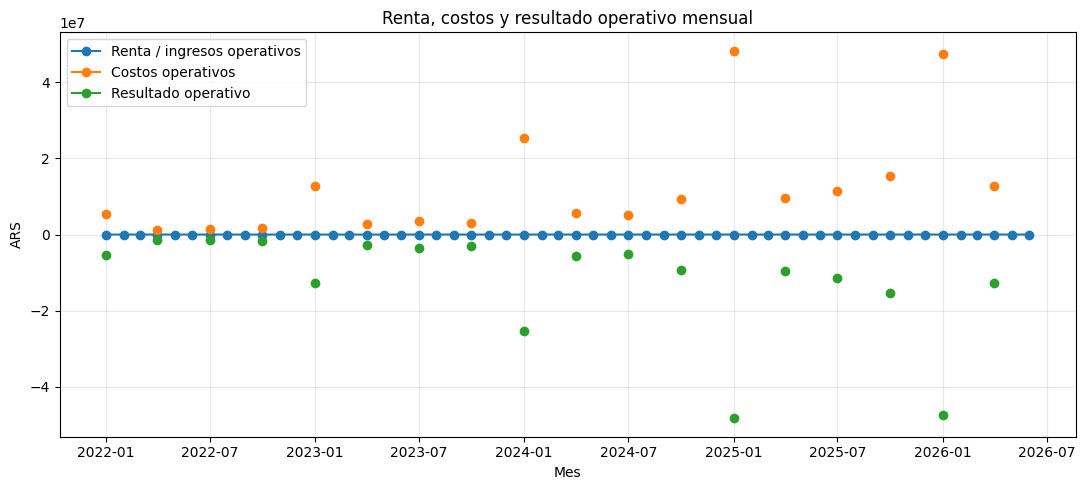

In [21]:
# -----------------------------
# Figure helpers
# -----------------------------

def save_current_figure(name):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()
    return path

plot_df = operating_monthly.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

# Figure 1: rent, opex, net monthly
plt.figure(figsize=(11, 5))
plt.plot(plot_df["date"], plot_df["rent_total"], marker="o", label="Renta / ingresos operativos")
plt.plot(plot_df["date"], plot_df["opex_total"], marker="o", label="Costos operativos")
plt.plot(plot_df["date"], plot_df["net_operating"], marker="o", label="Resultado operativo")
plt.title("Renta, costos y resultado operativo mensual")
plt.xlabel("Mes")
plt.ylabel("ARS")
plt.legend()
plt.grid(True, alpha=0.3)
fig1 = save_current_figure("rent_opex_net_monthly.png")

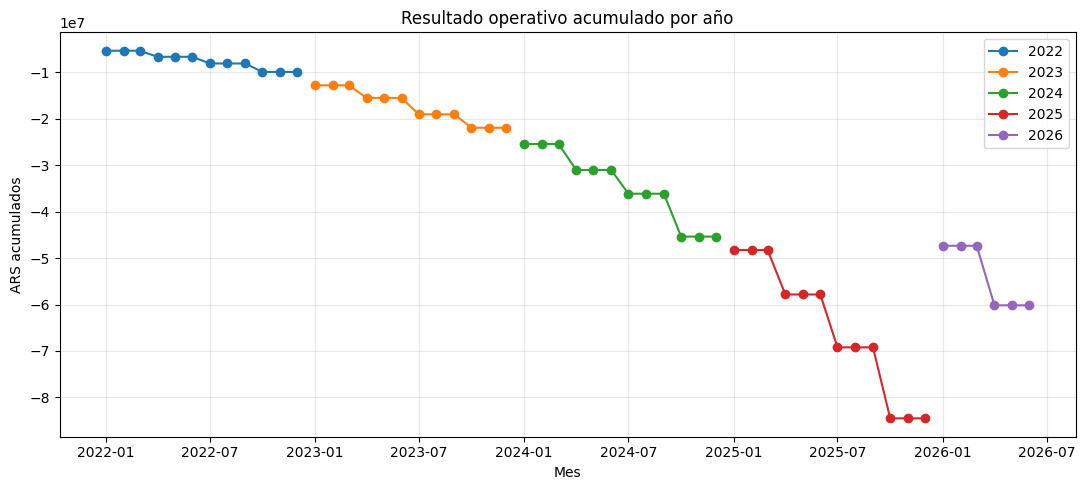

In [22]:
# Figure 2: cumulative net operating by year
cum_df = plot_df[["date", "year", "net_operating"]].copy()
cum_df = cum_df.sort_values("date")
cum_df["net_operating_filled"] = cum_df["net_operating"].fillna(0)
cum_df["net_operating_cumulative_ytd"] = cum_df.groupby("year")["net_operating_filled"].cumsum()

plt.figure(figsize=(11, 5))
for year, sub in cum_df.groupby("year"):
    plt.plot(sub["date"], sub["net_operating_cumulative_ytd"], marker="o", label=str(year))
plt.title("Resultado operativo acumulado por año")
plt.xlabel("Mes")
plt.ylabel("ARS acumulados")
plt.legend()
plt.grid(True, alpha=0.3)
fig2 = save_current_figure("net_operating_cumulative_by_year.png")

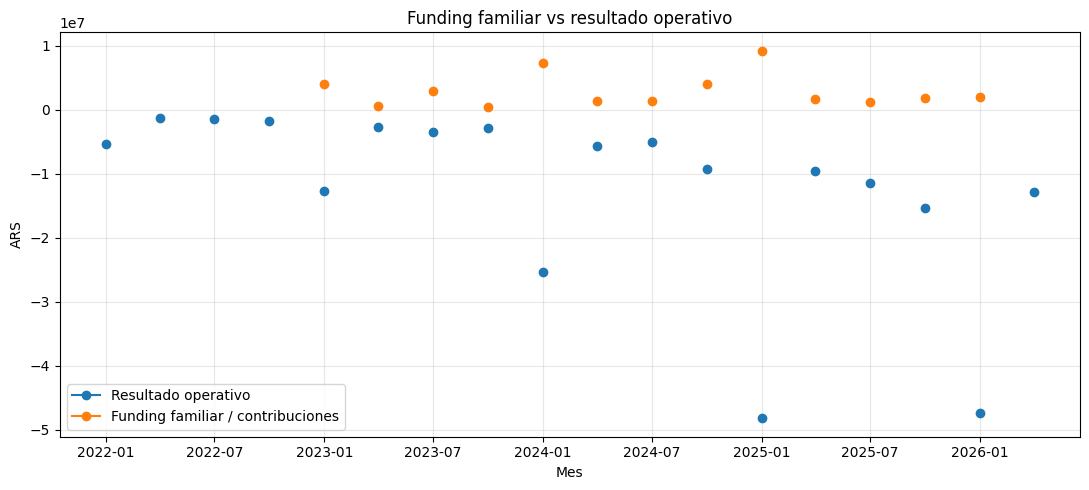

In [23]:
# Figure 3: funding vs net operating
plt.figure(figsize=(11, 5))
plt.plot(plot_df["date"], plot_df["net_operating"], marker="o", label="Resultado operativo")
plt.plot(plot_df["date"], plot_df["funding_total"], marker="o", label="Funding familiar / contribuciones")
plt.title("Funding familiar vs resultado operativo")
plt.xlabel("Mes")
plt.ylabel("ARS")
plt.legend()
plt.grid(True, alpha=0.3)
fig3 = save_current_figure("funding_vs_net_operating.png")

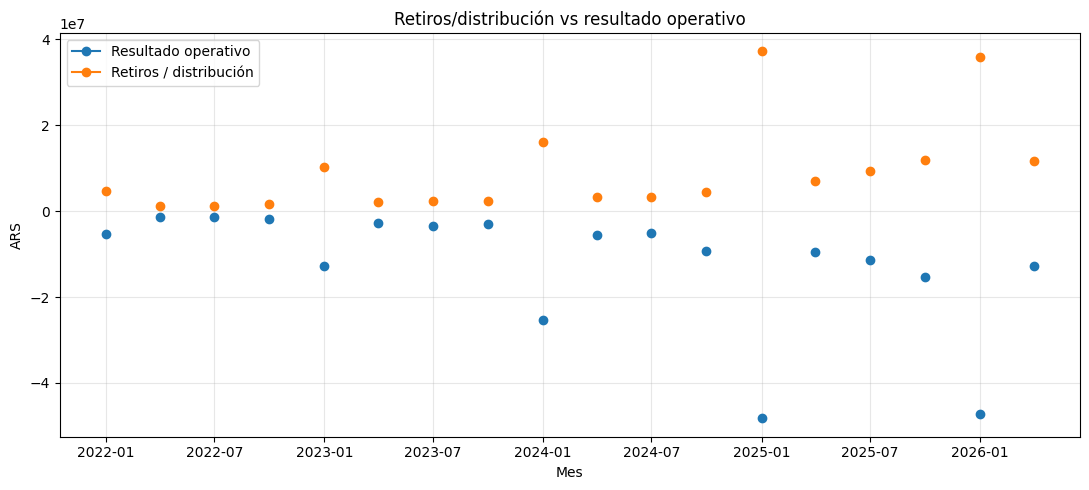

In [24]:
# Figure 4: draws vs net operating
plt.figure(figsize=(11, 5))
plt.plot(plot_df["date"], plot_df["net_operating"], marker="o", label="Resultado operativo")
plt.plot(plot_df["date"], plot_df["draws_total"], marker="o", label="Retiros / distribución")
plt.title("Retiros/distribución vs resultado operativo")
plt.xlabel("Mes")
plt.ylabel("ARS")
plt.legend()
plt.grid(True, alpha=0.3)
fig4 = save_current_figure("draws_vs_net_operating.png")

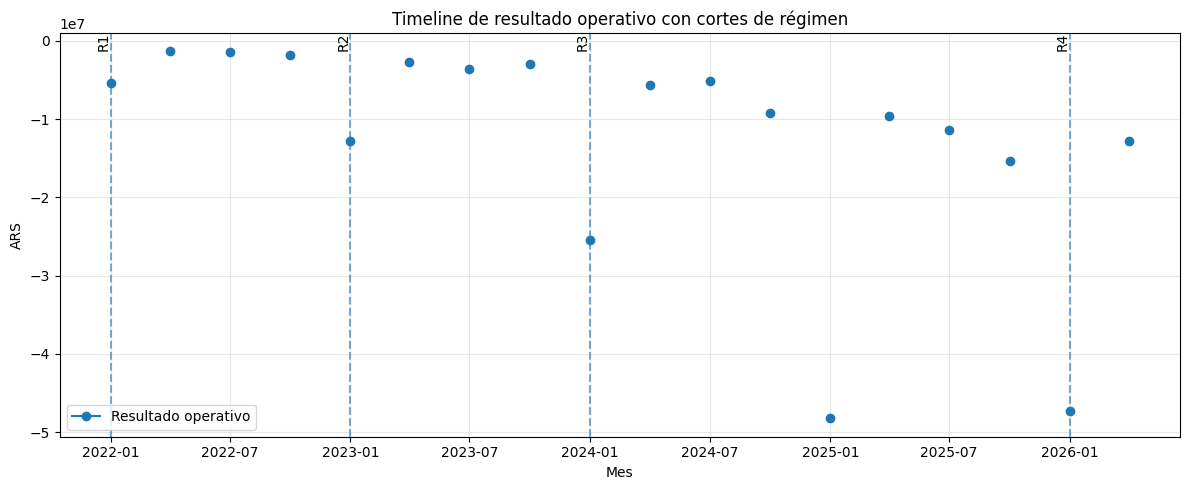

In [25]:
# Figure 5: regime timeline with vertical regime boundaries
plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["net_operating"], marker="o", label="Resultado operativo")
for _, r in regimes.iterrows():
    sp = parse_period_to_month(r.get("start_date", None))
    if pd.notna(sp):
        dt = sp.to_timestamp()
        if plot_df["date"].min() <= dt <= plot_df["date"].max():
            plt.axvline(dt, linestyle="--", alpha=0.6)
            plt.text(dt, plt.ylim()[1], str(r.get("regime_id", "")), rotation=90, va="top", ha="right")
plt.title("Timeline de resultado operativo con cortes de régimen")
plt.xlabel("Mes")
plt.ylabel("ARS")
plt.legend()
plt.grid(True, alpha=0.3)
fig5 = save_current_figure("regime_timeline.png")

## 11. Narrative generator

El reporte usa frases condicionales. Si una métrica falta, se degrada la afirmación. Si se usa fallback, se declara. Si el dato está parcial, no se sobreafirma.

In [26]:
# -----------------------------
# Narrative helpers
# -----------------------------

def safe_total(df, col):
    if df.empty or col not in df.columns:
        return np.nan
    return df[col].sum(min_count=1)

def safe_mean(df, col):
    if df.empty or col not in df.columns:
        return np.nan
    return df[col].mean()

def has_data(df, col):
    return (not df.empty) and (col in df.columns) and (df[col].notna().sum() > 0)

total_rent = safe_total(operating_monthly, "rent_total")
total_opex = safe_total(operating_monthly, "opex_total")
total_net = safe_total(operating_monthly, "net_operating")
total_funding = safe_total(operating_monthly, "funding_total")
total_draws = safe_total(operating_monthly, "draws_total")

sem = semester_summary.iloc[0].to_dict() if not semester_summary.empty else {}

def claim_revenue():
    if pd.isna(total_rent):
        return "La renta operativa todavía no puede afirmarse con magnitud agregada en este reporte porque falta una serie usable o un fallback consolidado."
    return f"En la ventana analizada, la renta/ingresos operativos suman {fmt_money(total_rent)}."

def claim_opex():
    if pd.isna(total_opex):
        return "Los costos operativos todavía no pueden resumirse con una serie consolidada; se requiere revisar opex views o clasificación."
    return f"Los costos operativos identificados suman {fmt_money(total_opex)}."

def claim_net():
    if pd.isna(total_net):
        return "El resultado operativo limpio no puede calcularse porque falta renta o costos operativos."
    if total_net >= 0:
        return f"Separando funding familiar de ingresos operativos, el resultado operativo acumulado es positivo: {fmt_money(total_net)}."
    return f"Separando funding familiar de ingresos operativos, el resultado operativo acumulado es negativo: {fmt_money(total_net)}."

def claim_funding():
    if pd.isna(total_funding):
        return "El funding familiar no aparece consolidado en una serie usable para toda la ventana."
    return f"El funding familiar/contribuciones aparece como una serie separada y suma {fmt_money(total_funding)}; no se lo trata como ingreso operativo."

def claim_draws():
    if pd.isna(total_draws):
        return "Los retiros/distribuciones no aparecen consolidados en una serie usable para toda la ventana."
    return f"Los retiros o salidas distributivas suman {fmt_money(total_draws)} y deben compararse contra margen operativo y caja, no contra renta bruta."

def claim_semester_close():
    if not sem:
        return f"No se pudo construir el cierre {close_label}."
    return (
        f"En {close_label}, el reporte muestra renta por {fmt_money(sem.get('rent_total'))}, "
        f"costos por {fmt_money(sem.get('opex_total'))}, resultado operativo por {fmt_money(sem.get('net_operating_total'))}, "
        f"funding por {fmt_money(sem.get('funding_total'))}, retiros por {fmt_money(sem.get('draws_total'))}, "
        f"caja de cierre {fmt_money(sem.get('cash_end'))} y deuda de cierre {fmt_money(sem.get('debt_end'))}."
    )

narrative_claims = [
    {"claim_id": "timeline_scope", "claim": f"El reporte cubre una serie mensual desde {HISTORY_START} hasta {HISTORY_END}, agrupada por año, semestre y régimen."},
    {"claim_id": "revenue", "claim": claim_revenue()},
    {"claim_id": "opex", "claim": claim_opex()},
    {"claim_id": "net_operating", "claim": claim_net()},
    {"claim_id": "funding", "claim": claim_funding()},
    {"claim_id": "draws", "claim": claim_draws()},
    {"claim_id": "semester_close", "claim": claim_semester_close()},
    {"claim_id": "governance", "claim": "La lectura de gobernanza no depende solo del total agregado: requiere observar cambios de régimen, trazabilidad, funding, retiros y cierre semestral."},
]

narrative_claims_df = pd.DataFrame(narrative_claims)
narrative_claims_df.to_csv(PACK / "operating_result_claims.csv", index=False)
display(narrative_claims_df)

,claim_id,claim
0,timeline_scope,El reporte cubre una serie mensual desde 2022-...
1,revenue,"En la ventana analizada, la renta/ingresos ope..."
2,opex,Los costos operativos identificados suman $ 22...
3,net_operating,Separando funding familiar de ingresos operati...
4,funding,El funding familiar/contribuciones aparece com...
5,draws,Los retiros o salidas distributivas suman $ 16...
6,semester_close,"En 2026H1, el reporte muestra renta por $ 2.28..."
7,governance,La lectura de gobernanza no depende solo del t...


## 12. QA checks

La notebook debe fallar suave pero visiblemente: si falta renta, costos, régimen o cierre semestral, lo registra. No oculta datos faltantes.

In [27]:
# -----------------------------
# QA checks
# -----------------------------

add_qa("has_monthly_spine", "ok" if len(operating_monthly) > 0 else "missing", f"{len(operating_monthly)} months")
add_qa("has_regime_map", "ok" if "regime_id" in operating_monthly.columns and operating_monthly["regime_id"].notna().any() else "missing", regime_source)
add_qa("has_revenue", "ok" if has_data(operating_monthly, "rent_total") else "missing", rent_source)
add_qa("has_opex", "ok" if has_data(operating_monthly, "opex_total") else "missing", opex_source)
add_qa("has_net_operating", "ok" if has_data(operating_monthly, "net_operating") else "missing", "rent_total - opex_total")
add_qa("no_funding_in_operating_result", "ok", "net_operating is calculated as rent_total - opex_total")
add_qa("has_funding_context", "ok" if has_data(operating_monthly, "funding_total") else "missing", funding_source)
add_qa("has_draws_context", "ok" if has_data(operating_monthly, "draws_total") else "missing", draws_source)
add_qa("has_cash_context", "ok" if has_data(operating_monthly, "cash_closing") else "missing", cash_source)
add_qa("has_debt_context", "ok" if has_data(operating_monthly, "debt_closing") else "missing", debt_source)
add_qa("single_monthly_base", "ok", "All report tables are joined to period_month spine")

# Identify major red flags as caveats.
if not has_data(operating_monthly, "rent_total"):
    add_caveat("revenue", "No rent/revenue series found. Revenue claims must be degraded.", "error")
if not has_data(operating_monthly, "opex_total"):
    add_caveat("opex", "No opex series found. Operating result cannot be computed reliably.", "error")
if "legacy_metric:" in str(funding_source) or "legacy_metric:" in str(draws_source):
    add_caveat("legacy_metrics", "Some context series use legacy metric namespaces. Check bridge metadata before external circulation.", "warning")

qa = pd.DataFrame(qa_rows).drop_duplicates()
caveats_df = pd.DataFrame(caveats).drop_duplicates()

qa.to_csv(PACK / "operating_result_qa.csv", index=False)
caveats_df.to_csv(PACK / "operating_result_caveats.csv", index=False)

display(qa)
display(caveats_df)

,check,status,details
0,metric_registry_loaded,ok,"(17, 14)"
1,metric_values_loaded,ok,"(287, 10)"
2,ledger_loaded,ok,"(1192, 26)"
3,regime_map_loaded,default,No regime_periods.csv found
4,legacy_comparison_available,ok,3 legacy series loaded
5,has_2026H1_close,ok,6 monthly rows
6,opex_by_category_available,ok,/home/matias/repos/accounting-backend/out/metr...
7,has_monthly_spine,ok,54 months
8,has_regime_map,ok,default
9,has_revenue,ok,file:renta_pivot.party_currency.csv


,scope,severity,message
0,regime_map,warning,No custom regime_periods.csv found. Using edit...
1,rent_total,warning,Used fallback file /home/matias/repos/accounti...
2,funding_total,warning,Used legacy metric IS.CONTRIB.TOTAL for fundin...
3,draws_total,warning,Used legacy metric IS.DRAWS.PERSONAL for draws...
4,debt_closing,warning,Used fallback file /home/matias/repos/accounti...
5,legacy_reconciliation,warning,Legacy IS metrics are shown for reconciliation...
6,legacy_metrics,warning,Some context series use legacy metric namespac...


## 13. Export report markdown and HTML

El reporte es el artifact narrativo. Las tablas y figuras quedan como soporte.

In [28]:
# -----------------------------
# Report export
# -----------------------------

figure_refs = [
    ("Renta, costos y resultado operativo mensual", "figures/rent_opex_net_monthly.png"),
    ("Resultado operativo acumulado por año", "figures/net_operating_cumulative_by_year.png"),
    ("Funding familiar vs resultado operativo", "figures/funding_vs_net_operating.png"),
    ("Retiros/distribución vs resultado operativo", "figures/draws_vs_net_operating.png"),
    ("Timeline con cortes de régimen", "figures/regime_timeline.png"),
]

def df_to_markdown_table(df, max_rows=12):
    if df.empty:
        return "_Sin datos._"
    try:
        return df.head(max_rows).to_markdown(index=False)
    except Exception:
        return df.head(max_rows).to_csv(index=False)

def caveat_bullets():
    if caveats_df.empty:
        return "- Sin caveats automáticos relevantes."
    lines = []
    for _, r in caveats_df.iterrows():
        lines.append(f"- **{r.get('severity','warning')} / {r.get('scope','')}:** {r.get('message','')}")
    return "\\n".join(lines)

def qa_summary_text():
    if qa.empty:
        return "- Sin QA."
    lines = []
    for _, r in qa.iterrows():
        lines.append(f"- `{r.get('check')}`: **{r.get('status')}** — {r.get('details','')}")
    return "\\n".join(lines)

report_lines = []
report_lines.append("# Informe temporal de resultado operativo")
report_lines.append("")
report_lines.append(f"Generado: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
report_lines.append(f"Ventana: `{HISTORY_START}` a `{HISTORY_END}`")
report_lines.append(f"Cierre semestral: `{close_label}`")
report_lines.append("")
report_lines.append("## Lectura ejecutiva")
report_lines.append("")
report_lines.append("Este informe analiza la operación patrimonial como una serie temporal. No mezcla aportes familiares con ingresos operativos. El objetivo es distinguir operación, funding, retiros, caja, deuda y cambios de régimen.")
report_lines.append("")
for c in narrative_claims:
    report_lines.append(f"- {c['claim']}")
report_lines.append("")
report_lines.append("## Fuentes resueltas")
report_lines.append("")
report_lines.append(df_to_markdown_table(sources))
report_lines.append("")
report_lines.append("## Cierre semestral")
report_lines.append("")
report_lines.append(df_to_markdown_table(semester_summary))
report_lines.append("")
report_lines.append("## Comparación por régimen")
report_lines.append("")
report_lines.append(df_to_markdown_table(operating_by_regime))
report_lines.append("")
report_lines.append("## Figuras")
report_lines.append("")
for title, rel in figure_refs:
    report_lines.append(f"### {title}")
    report_lines.append(f"![{title}]({rel})")
    report_lines.append("")
report_lines.append("## Tablas exportadas")
report_lines.append("")
for fname in [
    "operating_result_monthly.csv",
    "operating_result_by_regime.csv",
    f"semester_close_{close_label}.csv",
    "clean_vs_legacy_reconciliation.csv",
    "support_source_audit.csv",
    "opex_by_category.csv",
    "operating_result_caveats.csv",
    "operating_result_qa.csv",
]:
    report_lines.append(f"- `{fname}`")
report_lines.append("")
report_lines.append("## Caveats y límites")
report_lines.append("")
report_lines.append(caveat_bullets())
report_lines.append("")
report_lines.append("## QA")
report_lines.append("")
report_lines.append(qa_summary_text())
report_lines.append("")
report_lines.append("## Próximo uso recomendado")
report_lines.append("")
report_lines.append("Usar este reporte como soporte temporal del executive brief. Si el brief necesita afirmar renta, margen, funding o cierre semestral, debe tomar sus números de estas tablas o declarar caveats.")
report_md = "\\n".join(report_lines)

md_path = PACK / "operating_result_report.md"
md_path.write_text(report_md, encoding="utf-8")

# Minimal HTML conversion: enough for reading, preserves images.
def simple_markdown_to_html(md_text):
    lines = md_text.splitlines()
    out = [
        "<!doctype html>",
        "<html lang='es'>",
        "<head><meta charset='utf-8'><title>Informe temporal de resultado operativo</title>",
        "<style>body{font-family:system-ui,-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;max-width:980px;margin:40px auto;padding:0 24px 60px;color:#1f2937;line-height:1.45} h1{border-bottom:2px solid #d1d5db;padding-bottom:10px} h2{margin-top:30px} code{background:#f3f4f6;padding:2px 5px;border-radius:4px} table{border-collapse:collapse;width:100%;font-size:13px} th,td{border:1px solid #e5e7eb;padding:6px;text-align:left} img{max-width:100%;border:1px solid #e5e7eb}</style>",
        "</head><body>"
    ]
    in_ul = False
    in_table = False
    table_lines = []

    def flush_ul():
        nonlocal in_ul
        if in_ul:
            out.append("</ul>")
            in_ul = False

    def flush_table():
        nonlocal in_table, table_lines
        if not in_table:
            return
        rows = table_lines
        out.append("<table>")
        for i, row in enumerate(rows):
            cells = [html.escape(c.strip()) for c in row.strip().strip("|").split("|")]
            if i == 1 and set("".join(cells).replace(" ", "")) <= set("-:"):
                continue
            tag = "th" if i == 0 else "td"
            out.append("<tr>" + "".join(f"<{tag}>{c}</{tag}>" for c in cells) + "</tr>")
        out.append("</table>")
        table_lines = []
        in_table = False

    for line in lines:
        if line.startswith("|") and line.endswith("|"):
            flush_ul()
            in_table = True
            table_lines.append(line)
            continue
        else:
            flush_table()

        if not line.strip():
            flush_ul()
            out.append("")
            continue
        if line.startswith("# "):
            flush_ul()
            out.append(f"<h1>{html.escape(line[2:].strip())}</h1>")
        elif line.startswith("## "):
            flush_ul()
            out.append(f"<h2>{html.escape(line[3:].strip())}</h2>")
        elif line.startswith("### "):
            flush_ul()
            out.append(f"<h3>{html.escape(line[4:].strip())}</h3>")
        elif line.startswith("- "):
            if not in_ul:
                out.append("<ul>")
                in_ul = True
            txt = html.escape(line[2:].strip())
            txt = re.sub(r"`([^`]+)`", r"<code>\\1</code>", txt)
            txt = re.sub(r"\\*\\*([^*]+)\\*\\*", r"<strong>\\1</strong>", txt)
            out.append(f"<li>{txt}</li>")
        elif line.startswith("!["):
            flush_ul()
            m = re.match(r"!\\[(.*?)\\]\\((.*?)\\)", line)
            if m:
                alt, src = html.escape(m.group(1)), html.escape(m.group(2))
                out.append(f"<img alt='{alt}' src='{src}'>")
        else:
            flush_ul()
            txt = html.escape(line)
            txt = re.sub(r"`([^`]+)`", r"<code>\\1</code>", txt)
            txt = re.sub(r"\\*\\*([^*]+)\\*\\*", r"<strong>\\1</strong>", txt)
            out.append(f"<p>{txt}</p>")
    flush_ul()
    flush_table()
    out.append("</body></html>")
    return "\\n".join(out)

html_path = PACK / "operating_result_report.html"
html_path.write_text(simple_markdown_to_html(report_md), encoding="utf-8")

print("Wrote:", md_path)
print("Wrote:", html_path)
print("Output directory:", PACK)

Wrote: /home/matias/repos/accounting-backend/out/professional_pack/latest/operating_result/operating_result_report.md
Wrote: /home/matias/repos/accounting-backend/out/professional_pack/latest/operating_result/operating_result_report.html
Output directory: /home/matias/repos/accounting-backend/out/professional_pack/latest/operating_result


## 14. Definition of done

Este notebook está listo si:

- genera `operating_result_monthly.csv`;
- genera `operating_result_by_regime.csv`;
- genera `semester_close_2026H1.csv`;
- produce 5 figuras con sentido narrativo;
- separa resultado operativo de funding familiar;
- exporta caveats y QA;
- produce `operating_result_report.md` y `operating_result_report.html`;
- no afirma magnitudes cuando faltan fuentes.